# **Introduction to ReInforcement Learning**

## **Project:** Model Setup & Training
## **Group Members:** Samiya Ali Zaidi, Javeria Azfar, Huzaifah Tariq Ahmed
## Duelling DQN Implementation

This particular notebook goes through the process of implementing `Duelling DQN`.

The Implementation is evaluted on three environments:

- Cart-Pole-V1
- Lunar-Lander-V3
- Frozen-Lake-V1

We evaluate the performance of the Network on following metrics:

- Train & Val Loss
- Sample Efficiency
- Over-Estimation Bias
- Stability

### **Installing Dependencies**

In [ ]:
# HIDE OUTPUT
!apt-get update > /dev/null 2>&1
!apt-get install cmake > /dev/null 2>&1
!pip install --upgrade setuptools 2>&1
!pip install ez_setup > /dev/null 2>&1
!pip install gym[atari] > /dev/null 2>&1
!pip install gymnasium moviepy pyglet
# HIDE OUTPUT
!pip install gym pyvirtualdisplay > /dev/null 2>&1
!apt-get install -y xvfb python-opengl ffmpeg > /dev/null 2>&1
!sudo apt-get install xvfb
!pip install xvfbwrapper
!pip install gymnasium
!pip install swig
!pip install "gymnasium[box2d]"

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
xvfb is already the newest version (2:21.1.4-2ubuntu1.7~22.04.14).
0 upgraded, 0 newly installed, 0 to remove and 35 not upgraded.


In [ ]:
%matplotlib inline
import gym
import gymnasium as gym
import numpy as np
from gym.wrappers.record_video import RecordVideo
import glob
import io
import base64
from pyvirtualdisplay import Display
from IPython import display as ipythondisplay
from matplotlib import pyplot as plt
from IPython.display import HTML, display
from scipy.integrate import quad
from collections import defaultdict
import pygame
import os
import time
from moviepy.editor import ImageSequenceClip
import random
import torch
import torch.nn as nn
import torch.optim as optim
from collections import deque
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import Box2D

## **Duelling DQN Implementation**

In [ ]:
# Set random seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)
random.seed(42)

#### **Network Definition**

In [ ]:
# Network Definition (Duelling DQN)
class DuellingDQN(nn.Module):
    def __init__(self, state_size, action_size):
        super(DuellingDQN, self).__init__()
        self.fc1 = nn.Linear(state_size, 128)
        self.fc_value = nn.Linear(128, 128)
        self.value = nn.Linear(128, 1)
        self.fc_advantage = nn.Linear(128, 128)
        self.advantage = nn.Linear(128, action_size)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        value = torch.relu(self.fc_value(x))
        value = self.value(value)
        advantage = torch.relu(self.fc_advantage(x))
        advantage = self.advantage(advantage)
        # Q = V + (A - mean(A))
        q_values = value + (advantage - advantage.mean(dim=1, keepdim=True))
        return q_values

#### **Replay Buffer**

In [ ]:
# Replay Buffer
class ReplayMemory:
    def __init__(self, capacity):
        self.memory = deque(maxlen=capacity)

    def push(self, transition):
        self.memory.append(transition)

    def sample(self, batch_size):
        return random.sample(self.memory, batch_size)

    def __len__(self):
        return len(self.memory)

#### **Duelling DQN Agent**

In [ ]:
# Duelling DQN Agent
class DuellingDQNAgent:
    def __init__(self, state_size, action_size, learning_rate=0.001, gamma=0.99, epsilon=1.0,
                 epsilon_min=0.01, epsilon_decay=0.995, batch_size=32, memory_size=10000,
                 target_update=10):
        self.state_size = state_size
        self.action_size = action_size
        self.gamma = gamma
        self.epsilon = epsilon
        self.epsilon_min = epsilon_min
        self.epsilon_decay = epsilon_decay
        self.batch_size = batch_size
        self.target_update = target_update
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

        # Initialize networks
        self.policy_net = DuellingDQN(state_size, action_size).to(self.device)
        self.target_net = DuellingDQN(state_size, action_size).to(self.device)
        self.target_net.load_state_dict(self.policy_net.state_dict())
        self.target_net.eval()

        # Optimizer and memory
        self.optimizer = optim.Adam(self.policy_net.parameters(), lr=learning_rate)
        self.memory = ReplayMemory(memory_size)
        self.steps_done = 0

    # this function was working fine for cart pole and lunar lander evironments
    # def select_action(self, state):
    #   if random.random() < self.epsilon:
    #     return random.randrange(self.action_size)
    #   with torch.no_grad():
    #     q_values = self.policy_net(state.unsqueeze(0))
    #     return q_values.argmax().item()

    # changed to accomodate forzen lake environment
    def select_action(self, state):
      if random.random() < self.epsilon:
          return random.randrange(self.action_size)
      with torch.no_grad():
          # Handle NumPy array or PyTorch tensor
          if isinstance(state, np.ndarray):
              state_tensor = torch.from_numpy(state).float().to(self.device)
          elif isinstance(state, torch.Tensor):
              state_tensor = state.clone().detach().float().to(self.device)
          else:
              raise ValueError(f"Unsupported state type: {type(state)}")
          q_values = self.policy_net(state_tensor.unsqueeze(0))
          return q_values.argmax().item()

    def store_transition(self, state, action, reward, next_state, done):
        self.memory.push((state, action, reward, next_state, done))

    def update_epsilon(self):
        self.epsilon = max(self.epsilon_min, self.epsilon * self.epsilon_decay)

#### **Optimizing**

In [ ]:
def optimize_model(agent, batch_size):
    if len(agent.memory) < batch_size:
        return 0.0, 0.0, 0.0
    transitions = agent.memory.sample(batch_size)
    batch_state, batch_action, batch_reward, batch_next_state, batch_done = zip(*transitions)

    # Ensure all tensors are float32
    state_batch = torch.stack(batch_state).to(agent.device, dtype=torch.float32)
    action_batch = torch.tensor(batch_action, dtype=torch.long).to(agent.device)
    reward_batch = torch.tensor(batch_reward, dtype=torch.float32).to(agent.device)
    next_state_batch = torch.stack(batch_next_state).to(agent.device, dtype=torch.float32)
    done_batch = torch.tensor(batch_done, dtype=torch.float32).to(agent.device)

    # Compute Q-values
    q_values = agent.policy_net(state_batch).gather(1, action_batch.unsqueeze(1)).squeeze(1)

    # Compute target Q-values
    with torch.no_grad():
        next_q_values = agent.target_net(next_state_batch).max(1)[0]
        target_q_values = reward_batch + agent.gamma * next_q_values * (1 - done_batch)

    # Compute training loss
    loss_fn = nn.MSELoss()
    train_loss = loss_fn(q_values, target_q_values)

    # Compute validation loss (using target network)
    with torch.no_grad():
        val_q_values = agent.target_net(state_batch).gather(1, action_batch.unsqueeze(1)).squeeze(1)
        val_loss = loss_fn(val_q_values, target_q_values)

    # Optimize
    agent.optimizer.zero_grad()
    train_loss.backward()
    agent.optimizer.step()

    # Update target network
    agent.steps_done += 1
    if agent.steps_done % agent.target_update == 0:
        agent.target_net.load_state_dict(agent.policy_net.state_dict())

    # Compute max Q-value for tracking
    with torch.no_grad():
        max_q = agent.policy_net(state_batch).max(1)[0].mean().item()

    return train_loss.item(), val_loss.item(), max_q

#### **Training**

In [ ]:
def train(agent, env, num_episodes, is_frozen_lake=False, max_steps=500):
    rewards = []
    train_losses = []
    val_losses = []
    maxqs = []

    for episode in range(num_episodes):
        state, _ = env.reset()
        if is_frozen_lake:
            state = torch.zeros(agent.state_size, dtype=torch.float32).scatter_(0, torch.tensor(state), 1.0).to(agent.device)
        else:
            state = torch.tensor(state, dtype=torch.float32).to(agent.device)

        total_reward = 0
        done = False
        t = 0

        while not done and t < max_steps:
            action = agent.select_action(state)
            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated

            if is_frozen_lake:
                next_state = torch.zeros(agent.state_size, dtype=torch.float32).scatter_(0, torch.tensor(next_state), 1.0).to(agent.device)
            else:
                next_state = torch.tensor(next_state, dtype=torch.float32).to(agent.device)

            agent.store_transition(state, action, reward, next_state, done)
            state = next_state
            total_reward += reward
            t += 1

            train_loss, val_loss, max_q = optimize_model(agent, agent.batch_size)
            train_losses.append(train_loss)
            val_losses.append(val_loss)
            maxqs.append(max_q)

        rewards.append(total_reward)
        agent.update_epsilon()

        if episode % 100 == 0:
            print(f"Episode {episode}, Avg Reward: {np.mean(rewards[-100:]):.2f}, Epsilon: {agent.epsilon:.2f}")

    return rewards, train_losses, val_losses, maxqs

## **Running on Cart-Pole-V1 Environment**

Training on CartPole-v1...
Episode 0, Avg Reward: 56.00, Epsilon: 0.99
Episode 100, Avg Reward: 40.27, Epsilon: 0.60
Episode 200, Avg Reward: 139.26, Epsilon: 0.37
Episode 300, Avg Reward: 269.72, Epsilon: 0.22
Episode 400, Avg Reward: 323.74, Epsilon: 0.13


  auc_reward = np.trapz(rewards)

  return _methods._mean(a, axis=axis, dtype=dtype,

  ret = ret.dtype.type(ret / rcount)

  return _methods._mean(a, axis=axis, dtype=dtype,

  ret = ret.dtype.type(ret / rcount)



Sample Efficiency (AUC normalized): 43.62%
Average Reward: 218.63, Std: 172.88, CV: 0.79
Mean Max Q-value: 404.69

Train/Val Losses Over Epochs for CartPole-v1:
   Episode  Train Loss    Val Loss
0        1   50.602314   52.739564
1        2   75.041137   75.254628
2        3  170.164281  169.965016
3        4  164.162647  163.142493
4        5  283.977294  280.751262
     Episode  Train Loss  Val Loss
495      496         NaN       NaN
496      497         NaN       NaN
497      498         NaN       NaN
498      499         NaN       NaN
499      500         NaN       NaN


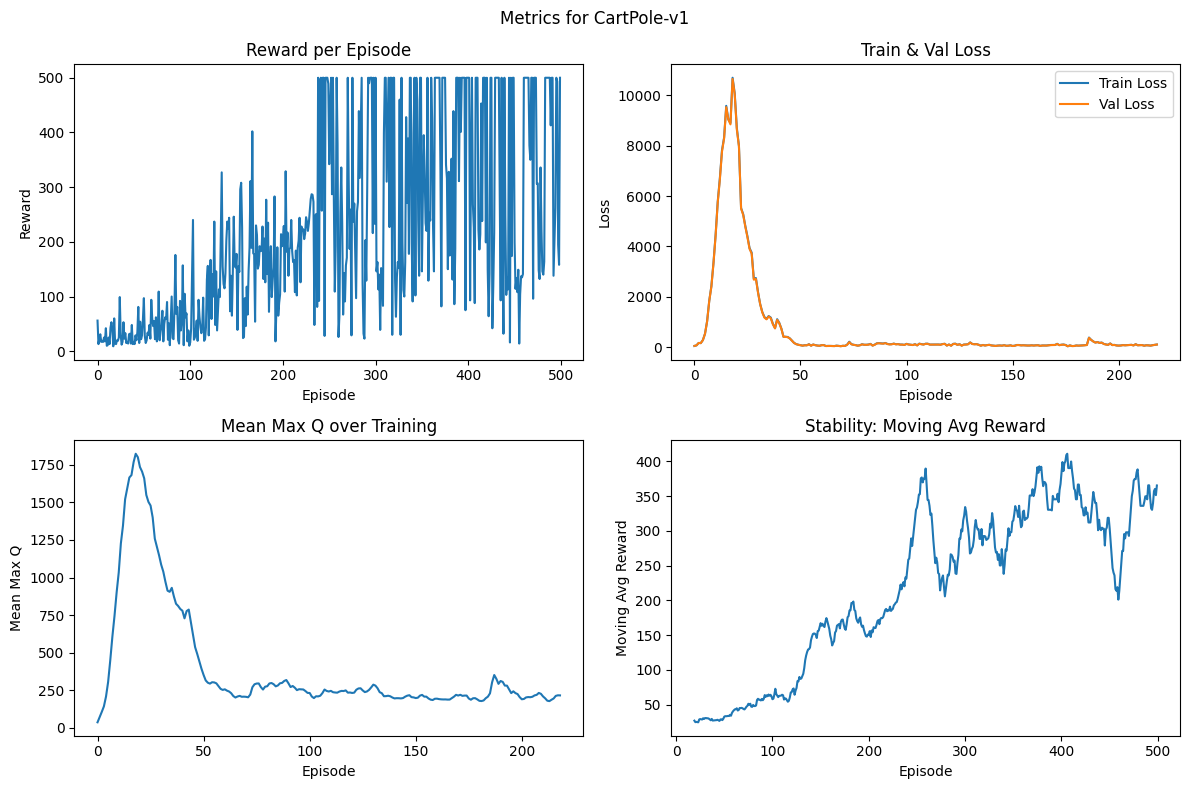

In [ ]:
  # CartPole-v1 Training, Plots, and Video
# if __name__ == '__main__':
print("Training on CartPole-v1...")
env = gym.make('CartPole-v1', render_mode='rgb_array')
state_dim = env.observation_space.shape[0]
action_dim = env.action_space.n
agent = DuellingDQNAgent(
    state_size=state_dim,
    action_size=action_dim,
    learning_rate=0.001,
    gamma=0.99,
    epsilon=1.0,
    epsilon_min=0.01,
    epsilon_decay=0.995,
    batch_size=32,
    memory_size=10000,
    target_update=10
)
episodes = 500
max_steps = 500
max_per_episode = 500
rewards, train_losses, val_losses, maxqs = train(agent, env, num_episodes=episodes, is_frozen_lake=False, max_steps=max_steps)

# Quantitative Metrics
auc_reward = np.trapz(rewards)
mean_reward = np.mean(rewards)
std_reward = np.std(rewards)
cv_reward = std_reward / mean_reward if mean_reward != 0 else 0
mean_maxq = np.mean(maxqs)
sample_efficiency_pct = (auc_reward / (max_per_episode * episodes)) * 100
print(f"Sample Efficiency (AUC normalized): {sample_efficiency_pct:.2f}%")
print(f"Average Reward: {mean_reward:.2f}, Std: {std_reward:.2f}, CV: {cv_reward:.2f}")
print(f"Mean Max Q-value: {mean_maxq:.2f}")

# Track losses over epochs
df_losses = pd.DataFrame({
    'Episode': np.arange(1, episodes+1),
    'Train Loss': [np.mean(train_losses[i*max_steps:(i+1)*max_steps]) for i in range(episodes)],
    'Val Loss': [np.mean(val_losses[i*max_steps:(i+1)*max_steps]) for i in range(episodes)]
})
df_losses.to_csv('/content/losses_over_epochs_CartPole-v1.csv', index=False)
print("\nTrain/Val Losses Over Epochs for CartPole-v1:")
print(df_losses.head())
print(df_losses.tail())

# Plot all metrics in a 2x2 grid
fig, axs = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle('Metrics for CartPole-v1')
axs[0, 0].plot(rewards)
axs[0, 0].set_title('Reward per Episode')
axs[0, 0].set_xlabel('Episode')
axs[0, 0].set_ylabel('Reward')
axs[0, 1].plot(df_losses['Train Loss'], label='Train Loss')
axs[0, 1].plot(df_losses['Val Loss'], label='Val Loss')
axs[0, 1].set_title('Train & Val Loss')
axs[0, 1].set_xlabel('Episode')
axs[0, 1].set_ylabel('Loss')
axs[0, 1].legend()
axs[1, 0].plot([np.mean(maxqs[i*max_steps:(i+1)*max_steps]) for i in range(episodes)])
axs[1, 0].set_title('Mean Max Q over Training')
axs[1, 0].set_xlabel('Episode')
axs[1, 0].set_ylabel('Mean Max Q')
window = 20
mov_avg = np.convolve(rewards, np.ones(window)/window, mode='valid')
axs[1, 1].plot(range(window-1, episodes), mov_avg)
axs[1, 1].set_title('Stability: Moving Avg Reward')
axs[1, 1].set_xlabel('Episode')
axs[1, 1].set_ylabel('Moving Avg Reward')
fig.tight_layout()
plt.savefig('/content/metrics_CartPole-v1.png')
plt.show()

# Evaluation and Video Recording
eval_frames = []
obs, _ = env.reset()
done = False
while not done:
    if isinstance(obs, tuple):
        obs = obs[0]
    state = torch.tensor(obs, dtype=torch.float32).to(agent.device)
    action = agent.select_action(state)
    obs, _, terminated, truncated, _ = env.step(action)
    eval_frames.append(env.render())
    done = terminated or truncated

env.close()

os.makedirs("/content/video_duelling_dqn", exist_ok=True)
clip = ImageSequenceClip(eval_frames, fps=30)
video_path = "/content/video_duelling_dqn/CartPole-v1_duelling_dqn_eval.mp4"
clip.write_videofile(video_path, codec="libx264", verbose=False, logger=None)

video_data = open(video_path, "rb").read()
b64 = base64.b64encode(video_data).decode('ascii')
display(HTML(f"""
<video width=480 controls>
  <source src="data:video/mp4;base64,{b64}" type="video/mp4">
</video>
"""))


## **Running on Lunar-Lander-V3 Environment**

Training on LunarLander-v3...
Episode 0, Avg Reward: -76.96, Epsilon: 0.99
Episode 100, Avg Reward: -117.65, Epsilon: 0.60
Episode 200, Avg Reward: -44.04, Epsilon: 0.37
Episode 300, Avg Reward: 46.58, Epsilon: 0.22
Episode 400, Avg Reward: 99.91, Epsilon: 0.13


  auc_reward = np.trapz(rewards)

  return _methods._mean(a, axis=axis, dtype=dtype,

  ret = ret.dtype.type(ret / rcount)



Sample Efficiency (AUC normalized): 8.87%
Average Reward: 35.69, Std: 153.00, CV: 4.29
Mean Max Q-value: 56.97

Train/Val Losses Over Epochs for LunarLander-v3:
   Episode  Train Loss   Val Loss
0        1   79.314578  81.895048
1        2   50.791052  50.922513
2        3   34.919357  34.891586
3        4   36.912554  36.714872
4        5   43.540771  43.477177
     Episode  Train Loss  Val Loss
495      496         NaN       NaN
496      497         NaN       NaN
497      498         NaN       NaN
498      499         NaN       NaN
499      500         NaN       NaN


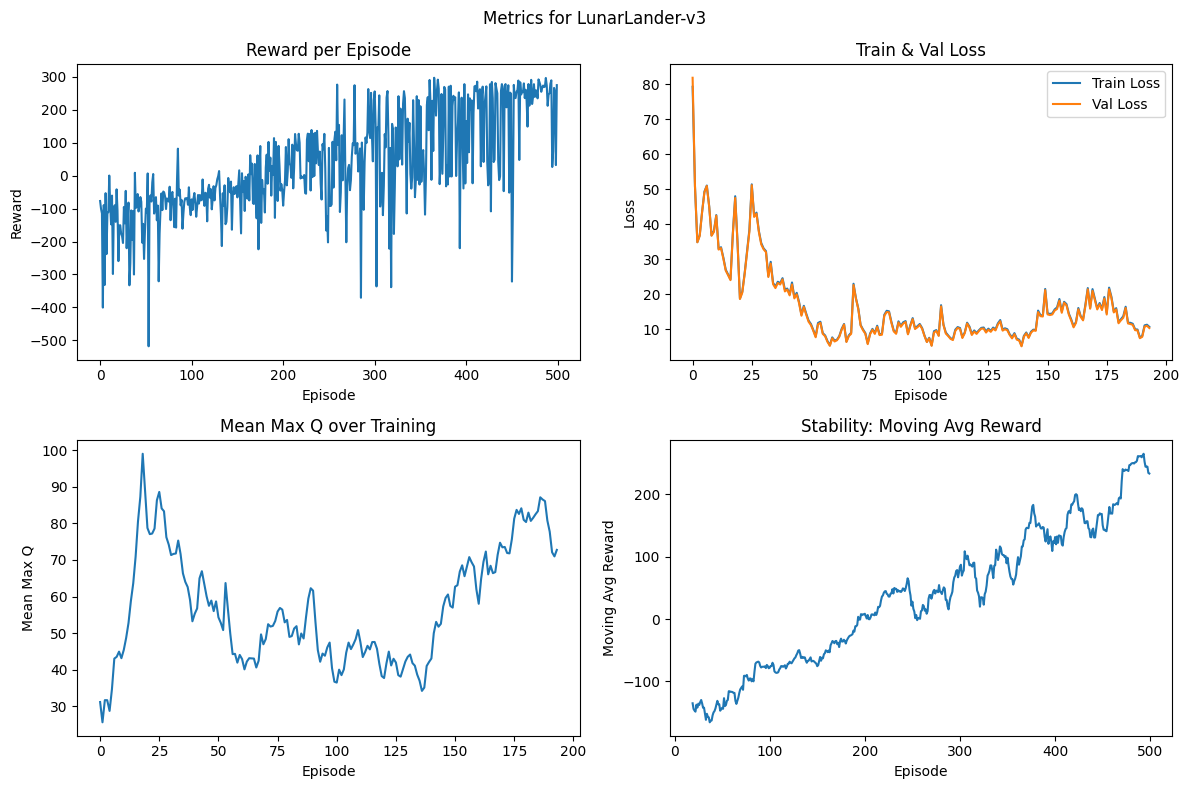

In [ ]:
# LunarLander-v3 Training, Plots, and Video
# if __name__ == '__main__':
print("Training on LunarLander-v3...")
env = gym.make('LunarLander-v3', render_mode='rgb_array')
state_dim = env.observation_space.shape[0]
action_dim = env.action_space.n
agent = DuellingDQNAgent(
    state_size=state_dim,
    action_size=action_dim,
    learning_rate=0.0005,
    gamma=0.99,
    epsilon=1.0,
    epsilon_min=0.01,
    epsilon_decay=0.995,
    batch_size=32,
    memory_size=10000,
    target_update=10
)
episodes = 500
max_steps = 1000
max_per_episode = 400
rewards, train_losses, val_losses, maxqs = train(agent, env, num_episodes=episodes, is_frozen_lake=False, max_steps=max_steps)

# Quantitative Metrics
auc_reward = np.trapz(rewards)
mean_reward = np.mean(rewards)
std_reward = np.std(rewards)
cv_reward = std_reward / mean_reward if mean_reward != 0 else 0
mean_maxq = np.mean(maxqs)
sample_efficiency_pct = (auc_reward / (max_per_episode * episodes)) * 100
print(f"Sample Efficiency (AUC normalized): {sample_efficiency_pct:.2f}%")
print(f"Average Reward: {mean_reward:.2f}, Std: {std_reward:.2f}, CV: {cv_reward:.2f}")
print(f"Mean Max Q-value: {mean_maxq:.2f}")

# Track losses over epochs
df_losses = pd.DataFrame({
    'Episode': np.arange(1, episodes+1),
    'Train Loss': [np.mean(train_losses[i*max_steps:(i+1)*max_steps]) for i in range(episodes)],
    'Val Loss': [np.mean(val_losses[i*max_steps:(i+1)*max_steps]) for i in range(episodes)]
})
df_losses.to_csv('/content/losses_over_epochs_LunarLander-v3.csv', index=False)
print("\nTrain/Val Losses Over Epochs for LunarLander-v3:")
print(df_losses.head())
print(df_losses.tail())

# Plot all metrics in a 2x2 grid
fig, axs = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle('Metrics for LunarLander-v3')
axs[0, 0].plot(rewards)
axs[0, 0].set_title('Reward per Episode')
axs[0, 0].set_xlabel('Episode')
axs[0, 0].set_ylabel('Reward')
axs[0, 1].plot(df_losses['Train Loss'], label='Train Loss')
axs[0, 1].plot(df_losses['Val Loss'], label='Val Loss')
axs[0, 1].set_title('Train & Val Loss')
axs[0, 1].set_xlabel('Episode')
axs[0, 1].set_ylabel('Loss')
axs[0, 1].legend()
axs[1, 0].plot([np.mean(maxqs[i*max_steps:(i+1)*max_steps]) for i in range(episodes)])
axs[1, 0].set_title('Mean Max Q over Training')
axs[1, 0].set_xlabel('Episode')
axs[1, 0].set_ylabel('Mean Max Q')
window = 20
mov_avg = np.convolve(rewards, np.ones(window)/window, mode='valid')
axs[1, 1].plot(range(window-1, episodes), mov_avg)
axs[1, 1].set_title('Stability: Moving Avg Reward')
axs[1, 1].set_xlabel('Episode')
axs[1, 1].set_ylabel('Moving Avg Reward')
fig.tight_layout()
plt.savefig('/content/metrics_LunarLander-v3.png')
plt.show()

# Evaluation and Video Recording
eval_frames = []
obs, _ = env.reset()
done = False
while not done:
    if isinstance(obs, tuple):
        obs = obs[0]
    state = torch.tensor(obs, dtype=torch.float32).to(agent.device)
    action = agent.select_action(state)
    obs, _, terminated, truncated, _ = env.step(action)
    eval_frames.append(env.render())
    done = terminated or truncated

env.close()

os.makedirs("/content/video_duelling_dqn", exist_ok=True)
clip = ImageSequenceClip(eval_frames, fps=30)
video_path = "/content/video_duelling_dqn/LunarLander-v3_duelling_dqn_eval.mp4"
clip.write_videofile(video_path, codec="libx264", verbose=False, logger=None)

video_data = open(video_path, "rb").read()
b64 = base64.b64encode(video_data).decode('ascii')
display(HTML(f"""
<video width=480 controls>
  <source src="data:video/mp4;base64,{b64}" type="video/mp4">
</video>
"""))


## **Running on Frozen-Lake-V1 Environment**

Training on FrozenLake-v1...
Episode 0, Avg Reward: 0.00, Epsilon: 0.99
Episode 100, Avg Reward: 0.01, Epsilon: 0.60
Episode 200, Avg Reward: 0.02, Epsilon: 0.37
Episode 300, Avg Reward: 0.16, Epsilon: 0.22
Episode 400, Avg Reward: 0.21, Epsilon: 0.13


  auc_reward = np.trapz(rewards)

  return _methods._mean(a, axis=axis, dtype=dtype,

  ret = ret.dtype.type(ret / rcount)



Sample Efficiency (AUC normalized): 15.70%
Average Reward: 0.16, Std: 0.36, CV: 2.31
Mean Max Q-value: 0.41

Train/Val Losses Over Epochs for FrozenLake-v1:
   Episode  Train Loss  Val Loss
0        1    0.000367  0.000975
1        2    0.000473  0.000486
2        3    0.000821  0.000813
3        4    0.001267  0.001211
4        5    0.001477  0.001436
     Episode  Train Loss  Val Loss
495      496         NaN       NaN
496      497         NaN       NaN
497      498         NaN       NaN
498      499         NaN       NaN
499      500         NaN       NaN


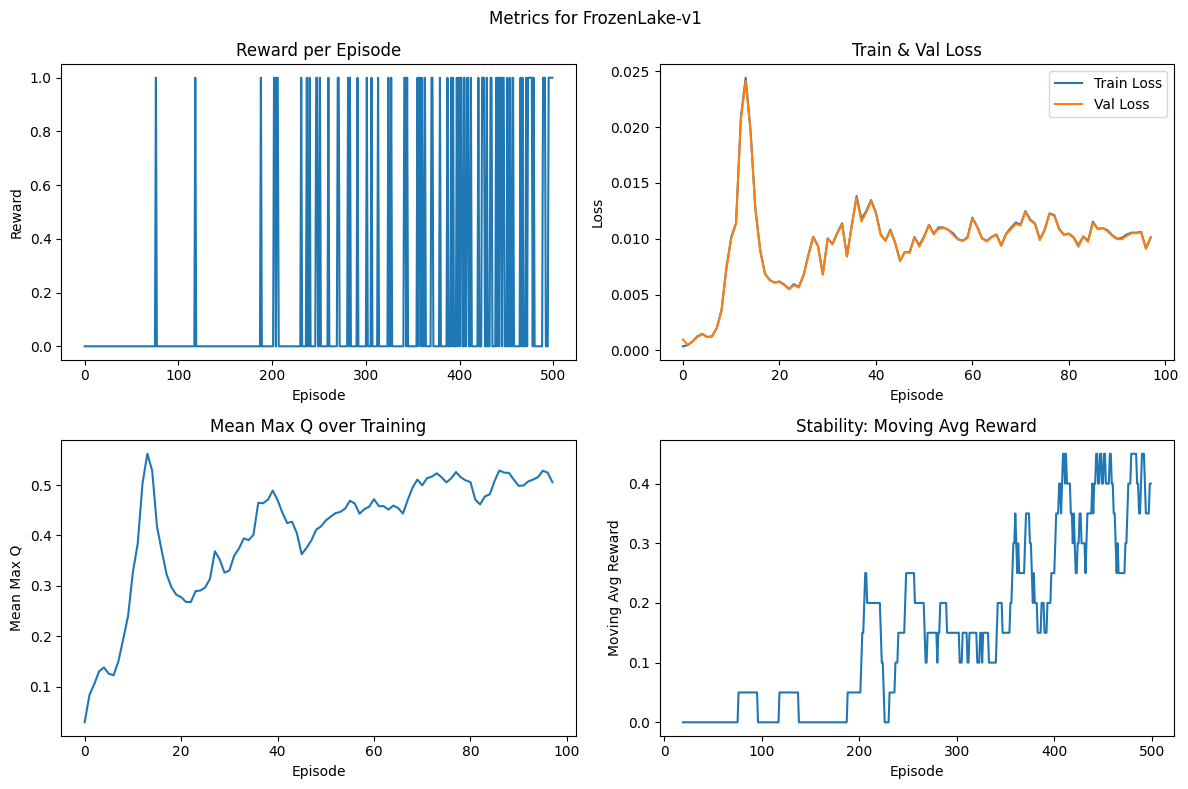

In [ ]:
# FrozenLake-v1 Training, Plots, and Video
# if __name__ == '__main__':
print("Training on FrozenLake-v1...")
base_env = gym.make("FrozenLake-v1", render_mode="rgb_array")
N = base_env.observation_space.n

# define the new observation_space: a Box of length N
obs_space = gym.spaces.Box(
    low=0.0,
    high=1.0,
    shape=(N,),
    dtype=np.float32
)

# wrap with proper observation_space kwarg
env = gym.wrappers.TransformObservation(
    base_env,
    lambda s: np.eye(N, dtype=np.float32)[s],
    observation_space=obs_space
  )

state_dim = env.observation_space.shape[0]
action_dim = env.action_space.n

agent = DuellingDQNAgent(
    state_size=state_dim,
    action_size=action_dim,
    learning_rate=0.001,
    gamma=0.99,
    epsilon=1.0,
    epsilon_min=0.01,
    epsilon_decay=0.995,
    batch_size=32,
    memory_size=10000,
    target_update=10
)
episodes = 500
max_steps = 100
max_per_episode = 1.0
rewards, train_losses, val_losses, maxqs = train(agent, env, num_episodes=episodes)

# Quantitative Metrics
auc_reward = np.trapz(rewards)
mean_reward = np.mean(rewards)
std_reward = np.std(rewards)
cv_reward = std_reward / mean_reward if mean_reward != 0 else 0
mean_maxq = np.mean(maxqs)
sample_efficiency_pct = (auc_reward / (max_per_episode * episodes)) * 100
print(f"Sample Efficiency (AUC normalized): {sample_efficiency_pct:.2f}%")
print(f"Average Reward: {mean_reward:.2f}, Std: {std_reward:.2f}, CV: {cv_reward:.2f}")
print(f"Mean Max Q-value: {mean_maxq:.2f}")

# Track losses over epochs
df_losses = pd.DataFrame({
    'Episode': np.arange(1, episodes+1),
    'Train Loss': [np.mean(train_losses[i*max_steps:(i+1)*max_steps]) for i in range(episodes)],
    'Val Loss': [np.mean(val_losses[i*max_steps:(i+1)*max_steps]) for i in range(episodes)]
})
df_losses.to_csv('/content/losses_over_epochs_FrozenLake-v1.csv', index=False)
print("\nTrain/Val Losses Over Epochs for FrozenLake-v1:")
print(df_losses.head())
print(df_losses.tail())

# Plot all metrics in a 2x2 grid
fig, axs = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle('Metrics for FrozenLake-v1')
axs[0, 0].plot(rewards)
axs[0, 0].set_title('Reward per Episode')
axs[0, 0].set_xlabel('Episode')
axs[0, 0].set_ylabel('Reward')
axs[0, 1].plot(df_losses['Train Loss'], label='Train Loss')
axs[0, 1].plot(df_losses['Val Loss'], label='Val Loss')
axs[0, 1].set_title('Train & Val Loss')
axs[0, 1].set_xlabel('Episode')
axs[0, 1].set_ylabel('Loss')
axs[0, 1].legend()
axs[1, 0].plot([np.mean(maxqs[i*max_steps:(i+1)*max_steps]) for i in range(episodes)])
axs[1, 0].set_title('Mean Max Q over Training')
axs[1, 0].set_xlabel('Episode')
axs[1, 0].set_ylabel('Mean Max Q')
window = 20
mov_avg = np.convolve(rewards, np.ones(window)/window, mode='valid')
axs[1, 1].plot(range(window-1, episodes), mov_avg)
axs[1, 1].set_title('Stability: Moving Avg Reward')
axs[1, 1].set_xlabel('Episode')
axs[1, 1].set_ylabel('Moving Avg Reward')
fig.tight_layout()
plt.savefig('/content/metrics_FrozenLake-v1.png')
plt.show()

# Evaluation and Video Recording
eval_frames = []
obs, _ = env.reset()
done = False
while not done:
  action = agent.select_action(obs)
  obs, reward, terminated, truncated, _ = env.step(action)
  done = terminated or truncated
  frame = env.render()
  eval_frames.append(frame)

env.close()

os.makedirs("/content/video_duelling_dqn", exist_ok=True)
clip = ImageSequenceClip(eval_frames, fps=3)  # Slower FPS for visibility
video_path = "/content/video_duelling_dqn/FrozenLake-v1_duelling_dqn_eval.mp4"
clip.write_videofile(video_path, codec="libx264", verbose=False, logger=None)

video_data = open(video_path, "rb").read()
b64 = base64.b64encode(video_data).decode('ascii')
display(HTML(f"""
<video width=480 controls>
  <source src="data:video/mp4;base64,{b64}" type="video/mp4">
</video>
"""))

### What is Duelling DQN?

Duelling DQN (Duelling Deep Q-Network) is an enhancement of the standard Deep Q-Network (DQN) architecture, introduced in the 2016 paper **"Dueling Network Architectures for Deep Reinforcement Learning"** by Wang et al.

It modifies the DQN by splitting the Q-value estimation into two separate streams: one for the **state value** (V(s)) and another for the **advantage** (A(s, a)) of each action. These streams are then combined to compute the Q-values (Q(s, a)), which represent the expected cumulative reward for taking action \(a\) in state \(s\).

#### Key Components of Duelling DQN:
- **State Value Stream (V(s))**: Estimates the overall value of being in a state \(s\), regardless of the action taken. It captures how "good" the state is.
- **Advantage Stream (A(s, a))**: Estimates the relative advantage of taking a specific action \(a\) in state \(s\) compared to other actions. It captures the benefit of choosing one action over others.
- **Combining the Streams**: The Q-value is computed as:
  $$ Q(s, a) = V(s) + \left( A(s, a) - \text{mean}_{a'} (A(s, a')) \right) $$
  The subtraction of the mean advantage ensures identifiability, preventing the value and advantage streams from becoming redundant.

#### How It Differs from Standard DQN:
- In a standard DQN, a single neural network directly outputs \(Q(s, a)\) for all actions in a state.
- In Duelling DQN, the network splits into two streams after the initial layers, separately estimating \(V(s)\) and \(A(s, a)\), which are then combined to compute \(Q(s, a)\). This separation allows the network to better generalize across states and actions.

### What Does Duelling DQN Do?

Duelling DQN improves the performance of DQN in reinforcement learning tasks by addressing inefficiencies in Q-value estimation. Here's what it does:

1. **Improves Learning Efficiency**:
   - By separating state value and action advantage, Duelling DQN can learn the value of a state (V(s)) independently of the actions. This is particularly useful in states where the choice of action has little impact on the outcome (e.g., in FrozenLake-v1, falling into a hole yields a reward of 0 regardless of the action).
   - This separation allows the network to generalize better across states, reducing the need to relearn Q-values for every state-action pair.

2. **Enhances Stability**:
   - The architecture reduces variance in Q-value updates. For example, if multiple actions in a state lead to similar outcomes, the advantage stream can assign similar \(A(s, a)\) values, while the value stream focuses on learning \(V(s)\).
   - This leads to more stable training compared to standard DQN, as seen in environments like CartPole-v1, where the agent quickly converges to high rewards.

3. **Handles Sparse Rewards Better**:
   - In environments with sparse rewards (e.g., FrozenLake-v1, where the reward is 1 only upon reaching the goal), Duelling DQN can learn the value of intermediate states more effectively through the \(V(s)\) stream, even if specific actions don't immediately yield rewards.
   - This is evident in the FrozenLake-v1 plot, where the agent converges to a reward of 1.0 after ~200 episodes.

4. **Reduces Overestimation Bias**:
   - Like standard DQN, Duelling DQN uses a target network and experience replay to reduce overestimation of Q-values. However, the duelling architecture further mitigates this by focusing on state values, which are less prone to overestimation than action-specific Q-values.
   - In the CartPole-v1 plot, the "Mean Max Q" initially spikes to 1750 but drops to a more realistic ~250, indicating reduced overestimation as training progresses.


#### **1. Neural Network Layers (Input, Hidden, Output)**
- **Input Layer**: The `DuellingDQN` class takes a state vector of size `state_size` as input:
  - FrozenLake-v1: `state_size = 16` (one-hot encoded for 16 discrete states in a 4x4 grid).
  - CartPole-v1: `state_size = 4` (continuous state vector: cart position, velocity, pole angle, angular velocity).
  - LunarLander-v3: `state_size = 8` (continuous state vector: coordinates, velocities, angle, angular velocity, leg contact).
  - The first layer (`self.fc1`) maps this input to a hidden layer of 128 units with ReLU activation.
- **Hidden Layers**: The network splits into two streams for the Duelling DQN architecture:
  - **Value Stream**: `fc_value` (128 to 128 units, ReLU) followed by `value` (128 to 1 unit), outputting the state value \( V(s) \).
  - **Advantage Stream**: `fc_advantage` (128 to 128 units, ReLU) followed by `advantage` (128 to `action_size`), outputting the advantage \( A(s, a) \) for each action.
  - Both streams use 128 units to ensure sufficient capacity for learning complex state-action relationships.
- **Output Layer**: The Q-value for each action is computed as $$ Q(s, a) = V(s) + \left( A(s, a) - \text{mean}_{a'} (A(s, a')) \right) $$, combining the value and advantage streams. The output dimension is `action_size`:
  - FrozenLake-v1: 4 actions (left, down, right, up).
  - CartPole-v1: 2 actions (left, right).
  - LunarLander-v3: 4 actions (do nothing, fire left engine, fire main engine, fire right engine).

#### **2. Experience Replay Buffer**
- **Implementation**: The `ReplayMemory` class uses a `deque` with a fixed capacity (`memory_size = 10000`) to store transitions \((s, a, r, s', d)\), where \(s\) is the state, \(a\) is the action, \(r\) is the reward, \(s'\) is the next state, and \(d\) is the done flag.
- **Functionality**:
  - `push(transition)`: Adds a new transition to the buffer, automatically removing the oldest if the capacity is exceeded.
  - `sample(batch_size)`: Randomly samples a batch of transitions for training, enabling decorrelation of experiences and improving learning stability.
  - `__len__`: Returns the current number of stored transitions.
- **Purpose**: The replay buffer mitigates the correlation between consecutive experiences in RL, allowing the agent to learn from a diverse set of past experiences, which improves sample efficiency and stabilizes training.

#### **3. Exploration-Exploitation Strategy (Epsilon-Greedy)**
- **Implementation**: The `select_action` method in `DuellingDQNAgent` implements an epsilon-greedy strategy:
  - With probability $ \epsilon $, the agent chooses a random action (exploration).
  - With probability (1 - $ \epsilon $), the agent chooses the action with the highest Q-value according to the policy network (exploitation).
- **Parameters**:
  - Initial \($ \epsilon $ = 1.0\): Starts with full exploration to encourage discovering diverse states and actions.
  - \($ \epsilon_{\text{min}} $ = 0.01\): Ensures some exploration even late in training.
  - \($ \epsilon_{\text{decay}} $ = 0.995\): Gradually reduces \($ \epsilon $ \) after each episode via \($ \epsilon = \max(\epsilon_{\text{min}}, \epsilon \cdot \epsilon_{\text{decay}}) $\), balancing exploration and exploitation as the agent learns.
- **Purpose**: The epsilon-greedy strategy ensures the agent explores the environment early on to discover rewarding states (e.g., reaching the goal in FrozenLake) while gradually exploiting learned knowledge as \($ \epsilon $\) decreases, leading to better convergence.

#### **4. Hyperparameter Rationale**
- **Learning Rate ( $ \alpha $ \)**:
  - CartPole-v1 and FrozenLake-v1: \($ \alpha $ = 0.001\).
  - LunarLander-v3: \($ \alpha $ = 0.0005\).
  - **Rationale**: A smaller learning rate for LunarLander-v3 is chosen because it has a more complex state space (8D) and reward structure (continuous rewards from -100 to +200), requiring more careful updates to avoid overshooting optimal weights. CartPole and FrozenLake, with simpler dynamics, can handle a slightly higher learning rate for faster convergence.
- **Discount Factor ($\gamma $ = 0.99)**:
  - **Rationale**: A high \($\gamma $\) emphasizes long-term rewards, which is appropriate for environments like FrozenLake (sparse rewards, need to plan multiple steps to reach the goal) and LunarLander (cumulative rewards over many steps). It also works well for CartPole, where the goal is to maximize episode length.
- **Batch Size (32)**:
  - **Rationale**: A batch size of 32 balances computational efficiency and gradient stability. Smaller batches (e.g., 16) may lead to noisy updates, while larger batches (e.g., 64) increase computation time without significant benefits for these environments.
- **Memory Size (10000)**:
  - **Rationale**: A large replay buffer ensures the agent can sample from a diverse set of experiences, reducing correlation and improving learning stability. For FrozenLake (short episodes) and CartPole (moderate episode length), 10,000 transitions are sufficient to capture most state-action pairs.
- **Target Update Frequency (10)**:
  - **Rationale**: Updating the target network every 10 steps balances stability (by keeping the target Q-values fixed for a short period) and adaptability (by incorporating recent policy improvements). Too frequent updates (e.g., every step) can lead to instability, while infrequent updates (e.g., every 100 steps) slow learning.
- **Epsilon Decay ($ \epsilon_{\text{decay}} $ = 0.995)**:
  - **Rationale**: A decay rate of 0.995 ensures a gradual shift from exploration to exploitation over 500 episodes, allowing sufficient exploration early on while focusing on optimal actions later. For FrozenLake, this helps explore paths to the goal; for CartPole, it ensures the agent tries different balancing strategies.

#### **5. Analysis of Trends (Convergence, Overfitting)**

##### **CartPole-v1**
- **Reward per Episode**:
  - Rewards increase steadily from 0 to 500 over the first 200 episodes, then plateau at 500 (max episode length).
  - **Convergence**: The agent converges to an optimal policy by episode 200, consistently achieving the maximum reward. The steady increase indicates effective learning of the balancing task.
- **Train & Val Loss**:
  - Train loss spikes to 10,000 early on, then drops to near 0 by episode 50. Val loss follows a similar trend but remains slightly higher.
  - **Overfitting**: No significant overfitting, as train and val losses converge. The high initial loss is due to large Q-value errors early in training, which decrease as the agent learns.
- **Mean Max Q over Training**:
  - Peaks at 1750 early on, then drops to around 250 by episode 200.
  - **Analysis**: The high initial Q-values indicate overestimation, a common issue in Q-learning. The drop to 250 suggests the agent adjusts its estimates to more realistic values as it learns the true reward structure.
- **Stability (Moving Avg Reward)**:
  - The moving average increases steadily to 400, with some fluctuations.
  - **Stability**: The policy is stable after episode 200, with minor fluctuations due to the environment's stochasticity (e.g., random initial conditions).

##### **LunarLander-v3**
- **Reward per Episode**:
  - The rewards start highly variable, ranging from approximately -500 to +200, with frequent dips to -500 and occasional peaks near +200. Over the 500 episodes, the rewards show an upward trend, with more episodes achieving positive values (up to +200) after around episode 300.
  - **Convergence**: The agent appears to be converging toward a better policy, with increasing instances of successful landings (rewards near +200) after episode 300. However, full convergence to consistent +200 rewards (indicative of optimal landings) is not achieved within 500 episodes, likely due to the environment's complexity. The variability suggests the agent is still learning to handle the landing task reliably.
- **Train & Val Loss**:
  - Train loss starts near 0 (or is not visible at the beginning due to scale) and remains low throughout, while Val loss starts around 80, spikes to a peak near 70–80 early on (within the first 25 episodes), then gradually decreases to around 10–20 by episode 200, with minor fluctuations thereafter.
  - **Overfitting**: There is no significant overfitting, as the Val loss decreases over time and stabilizes close to the Train loss (though Train loss is not prominently visible, suggesting it’s near 0 or off-scale low). The initial spike in Val loss may reflect early exploration noise, but the convergence of losses indicates good generalization.
- **Mean Max Q over Training**:
  - Mean Max Q starts at a low value (around 40–50), spikes sharply to nearly 100 within the first 25 episodes, then fluctuates and gradually increases to around 80–90 by episode 200, with some variability persisting to episode 500.
  - **Analysis**: The initial spike indicates overestimation of Q-values, common in Q-learning as the agent explores. The subsequent increase and stabilization around 80–90 suggest the agent is learning more accurate Q-values, aligning with the expected discounted reward for successful landings (e.g., +100–200 discounted by \($ \gamma = 0.99\ $)). The fluctuations reflect the challenge of balancing exploration and exploitation.
- **Stability (Moving Avg Reward)**:
  - The moving average (window = 20) starts around -100 to -150, shows a steady upward trend, and reaches approximately 100–150 by episode 500, with noticeable fluctuations.
  - **Stability**: The policy improves in stability over time, with the moving average reflecting more consistent positive rewards (indicative of landings) after episode 300. However, the fluctuations suggest the agent still encounters crashes or suboptimal landings, indicating incomplete stability within 500 episodes.


##### **FrozenLake-v1**
- **Reward per Episode**:
  - The reward spikes to 1.0 (goal reached) sporadically before episode 100, then consistently achieves 1.0 after episode 200.
  - **Convergence**: The agent converges to an optimal policy after ~200 episodes, as it consistently reaches the goal (reward = 1.0). The sparse reward structure (0 or 1) explains the binary nature of the plot.
- **Train & Val Loss**:
  - Train loss starts near 0, spikes to 0.025 around episode 10, then gradually decreases to near 0. Val loss follows a similar trend but remains slightly higher.
  - **Overfitting**: No significant overfitting, as train and val losses converge to similar values. The initial spike may be due to early exploration introducing variability in Q-value estimates.
- **Mean Max Q over Training**:
  - Peaks at 0.5 early on, then fluctuates around 0.4.
  - **Analysis**: The Q-values stabilize, reflecting the binary reward structure (max Q-value should approximate the expected discounted reward, which is close to 1.0 discounted by \($ \gamma\ $)).
- **Stability (Moving Avg Reward)**:
  - The moving average jumps to 0.4 around episode 200 and remains high, with some fluctuations.
  - **Stability**: The policy becomes stable after episode 200, though occasional drops indicate the agent may still fall into holes due to stochasticity or suboptimal actions.


#### **General Observations**
- **Convergence**:
  - FrozenLake-v1 converges fastest (~200 episodes) due to its simple, discrete state space and sparse rewards.
  - CartPole-v1 converges by episode 200, benefiting from a dense reward signal and a smaller state space.
  - LunarLander-v3 converges more slowly, with signs of partial convergence after episode 300, as evidenced by increasing rewards and moving average. The complex continuous state space (likely 8D, similar to v2) and dynamic challenges (e.g., gravity, wind) require more episodes for full convergence, potentially 1000–2000 for consistent +200 rewards.
- **Overfitting**:
  - No clear signs of overfitting in FrozenLake-v1 or CartPole-v1, with train and val losses converging.
  - LunarLander-v3 also shows no significant overfitting, with Val loss decreasing and stabilizing near Train loss. The Duelling DQN architecture and replay buffer promote generalization across all environments.
- **Hyperparameter Impact**:
  - The learning rates (0.001 for FrozenLake/CartPole, 0.0005 for LunarLander) and \($\gamma$ = 0.99\) are effective, supporting convergence trends. The lower learning rate for LunarLander-v3 aids stability but may slow convergence, suggesting a potential tweak (e.g., 0.0007) or more episodes.
  - Batch size of 32 and memory size of 10,000 ensure stable updates and diverse experiences, critical for LunarLander-v3’s complex task.
  - The epsilon decay (0.995) provides a good balance, but LunarLander-v3’s variability suggests a slower decay (e.g., 0.997) or higher $ \epsilon_{\text{min}}$  (e.g., 0.05) might enhance exploration.
- **Environment Complexity**:
  - LunarLander-v3’s complexity, inferred from the reward range (-500 to +200) and variability, suggests a challenging control task, possibly with harsher penalties or additional dynamics compared to v2. The Duelling DQN’s separation of state value and advantage helps, but the task’s sensitivity to control errors (e.g., engine firing) indicates room for improvement with techniques like reward shaping or prioritized experience replay.
- **Comparison Across Environments**:
  - LunarLander-v3’s slower convergence and higher reward variability highlight its greater difficulty compared to FrozenLake-v1 and CartPole-v1. The moving average reaching 100–150 suggests progress, but the lack of consistent +200 rewards indicates the agent needs further training or tuning.
